<a href="https://colab.research.google.com/github/ThiagoBrandaorj/Machine_learning/blob/main/C%C3%B3pia_de_02_Manuten%C3%A7%C3%A3o_preventiva.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **DESAFIO 02 - MANUTENÇÃO PREVENTIVA**

A base que utilizaremos representa dados operacionais de máquinas e a indicação de algum tipo de falha operacional que tenha sido detectado. A base pode carregada [daqui](https://github.com/cassiusf/datasets/raw/refs/heads/main/desafios/Dataset_Manutencao_Preventiva.csv) e o objetivo é prever eventuais situações que levem à parada operacional.


Este conjunto de dados reflete informações relacionadas à manutenção preditiva real encontrada na indústria, possuindo 10.000 registros e 14 variáveis:

- **UDI**: identificador único que varia de 1 a 10.000.
- **product ID**: consistindo em uma letra L, M ou H para baixo (50% de todos os produtos), médio (30%) e alto (20%) como variantes de qualidade do produto e um número de série específico da variante.
- **type**: letra relacionada ao ***product ID***
- **air temperature [K]**: gerada usando um processo de caminhada aleatória posteriormente normalizada para um desvio padrão de 2 K em torno de 300 K.
- **process temperature [K]**: gerada usando um processo de caminhada aleatória normalizado para um desvio padrão de 1 K, adicionado à temperatura do ar mais 10 K.
- **rotational speed [rpm]**: calculada a partir de uma potência de 2860 W, sobreposta com um ruído normalmente distribuído.
- **torque [Nm]**: os valores de torque são normalmente distribuídos em torno de 40 Nm com um Ïƒ = 10 Nm e sem valores negativos.
- **tool wear [min]**: as variantes de qualidade H/M/L adicionam 5/3/2 minutos de desgaste da ferramenta à ferramenta usada no processo. e um
O rótulo "falha da máquina" que indica se a máquina falhou neste ponto de dados específico para qualquer um dos seguintes modos de falha é verdadeiro.
- **machine failure**: rótulo que indica se a máquina falhou neste ponto de dados específico para qualquer um dos modos de falha abaixo.

As falhas consistem em cinco modos de falha independentes

- **Tool Wear Failure (TWF) (Falha de desgaste da ferramenta)**: a ferramenta passa por substituição ou apresenta falha em um tempo de desgaste da ferramenta entre 200 e 240 minutos.
- **Heat Dissipation Failure (HDF) (Falha de dissipação de calor)**: a dissipação de calor causa uma falha no processo, se a diferença entre a temperatura do ar e do processo estiver na faixa de 8.6K e a velocidade de rotação da ferramenta estiver abaixo de 1380 rpm.
- **Power Failure (PWF) (Falha de energia)**: o produto do torque e da velocidade de rotação (em rad/s) é igual à potência necessária para o processo. Se essa potência estiver abaixo de 3500 W ou acima de 9000 W, o processo falhará.
- **Overstrain Failure (OSF) (Falha por sobretensão)**: se o produto do desgaste e torque da ferramenta exceder 11.000 Nm para a variante do produto L, 12.000 para o M e 13.000 para o H, o processo falha devido a sobretensão.
- **Random Failures (RNF) (Falhas aleatórias)**: cada processo tem uma chance de falha de 0,1%, independentemente de seus parâmetros de processo.

Se pelo menos um dos modos de falha acima acontecer, o processo como um todo falhará e o rótulo `machine failure` será definido como 1. Portanto, não é totalmente transparente para o modelo de aprendizado de máquina qual dos modos de falha efetivamente foi responsável pela falha do processo.


## **TAREFA**

Seu objetivo é utilizar um modelo de machine learning rasa para prever a ocorrência de falhas mecânicas.

Utilize um modelo para benchmark diferente do seu modelo-alvo principal. Este benchmark será escolhido por você de acordo com o domínio da aplicação e será utilizado como referência a ser batida por seu modelo-alvo, que hipoteticamente será utilizado em produção.

Você deverá fazer todas es etapas necessárias tanto na avaliação dos dados disponíveis quanto na preparação necessária para execução dos modelos escolhidos.

Todas as etapas devem ser documentadas e as escolhas justificadas.

A performance do seu modelo deverá ser avaliada pelas métricas Acurácia, Precision, Recall e/ou F1-Score. Inclua em sua avaliação final de performance Curvas, ROC e/ou Precision-Recall, de acordo com a necessidade e a comparação de performance entre seu modelo-alvo e o benchmark proposto.

Iniciem hoje em sala e apresentem seus resultados apenas a partir do Colab na aula da semana que vem, dia 12/03/2026.



## EDA

In [ ]:
!pip install -q imbalanced-learn shap

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.mixture import GaussianMixture
import random
import sys
import platform
from sklearn.metrics import silhouette_score, davies_bouldin_score
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score
import warnings
warnings.filterwarnings('ignore')

In [ ]:
# Reprodutibilidade
SEED = 42
random.seed(SEED)
np.random.seed(SEED)

def show_versions():
    import sklearn, scipy
    vers = {
        "python": sys.version.split()[0],
        "platform": platform.platform(),
        "numpy": np.__version__,
        "pandas": pd.__version__,
        "scipy": scipy.__version__,
        "sklearn": sklearn.__version__,
    }
    try:
        import imblearn
        vers["imblearn"] = imblearn.__version__
    except Exception:
        vers["imblearn"] = "not installed"
    try:
        import shap
        vers["shap"] = shap.__version__
    except Exception:
        vers["shap"] = "not installed"
    return vers

VERSIONS = show_versions()
VERSIONS


{'python': '3.12.12',
 'platform': 'Linux-6.6.113+-x86_64-with-glibc2.35',
 'numpy': '2.0.2',
 'pandas': '2.2.2',
 'scipy': '1.16.3',
 'sklearn': '1.6.1',
 'imblearn': '0.14.1',
 'shap': '0.51.0'}

In [ ]:
df = pd.read_csv("https://raw.githubusercontent.com/cassiusf/datasets/refs/heads/main/desafios/Dataset_Manutencao_Preventiva.csv")
df.head()

,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


In [ ]:
df.shape

(10000, 14)

In [ ]:
df.columns

Index(['UDI', 'Product ID', 'Type', 'Air temperature [K]',
       'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]',
       'Tool wear [min]', 'Machine failure', 'TWF', 'HDF', 'PWF', 'OSF',
       'RNF'],
      dtype='object')

In [ ]:
df.dtypes

,0
UDI,int64
Product ID,object
Type,object
Air temperature [K],float64
Process temperature [K],float64
Rotational speed [rpm],int64
Torque [Nm],float64
Tool wear [min],int64
Machine failure,int64
TWF,int64


In [ ]:
# Verificar se há duplicatas
df.duplicated().sum()

np.int64(0)

**Não existem linhas duplicadas**

In [ ]:
# Ver o total de NAs em cada coluna
print(df.isna().sum())

# Ver quantas linhas têm pelo menos um NA
print(f"Linhas com NA: {df.isna().any(axis=0).sum()}")

UDI                        0
Product ID                 0
Type                       0
Air temperature [K]        0
Process temperature [K]    0
Rotational speed [rpm]     0
Torque [Nm]                0
Tool wear [min]            0
Machine failure            0
TWF                        0
HDF                        0
PWF                        0
OSF                        0
RNF                        0
dtype: int64
Linhas com NA: 0


**Não existem NAs na base**

In [ ]:
df['UDI'].nunique()

10000

**Podemos ver qua a variável 'UDI' se trata somente de um ID de cada registro, portanto iremos removê-la da base visto que esta variável não terá nenhuma utilidade na predição**

In [ ]:
df = df.drop(['UDI'],axis=1)

In [ ]:
# Lista das colunas de interesse
colunas = ['TWF', 'HDF', 'PWF', 'OSF', 'RNF']

# Filtrar linhas onde a soma dessas colunas é >= 2
df_filtrado = df[df[colunas].sum(axis=1) >= 2]
df_filtrado.head(100)

,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
69,L47249,L,298.9,309.0,1410,65.7,191,1,0,0,1,1,0
1324,M16184,M,298.8,310.1,1243,74.5,194,1,0,0,1,1,0
1496,L48676,L,298.0,308.7,1268,69.4,189,1,0,0,1,1,0
3611,L50791,L,301.7,310.9,1405,46.4,207,1,1,0,0,0,1
3854,L51034,L,302.4,311.0,1338,67.6,194,1,0,0,1,1,0
3943,L51123,L,302.3,311.4,1333,66.7,205,1,0,0,1,1,0
4254,L51434,L,302.6,311.0,1284,68.0,114,1,0,1,1,0,0
4342,M19202,M,301.7,309.8,1284,68.2,111,1,0,1,1,0,0
4370,L51550,L,302.0,309.9,1308,57.6,197,1,0,1,0,1,0
4383,L51563,L,301.7,309.5,1298,65.5,229,1,0,1,0,1,0


**Podemos perceber que os motivos da falha simplesmente não são mutuamente exclusivas, portanto predizer o motivo da falha atráves de uma classificação multiclasse não será possível, portanto iremos para uma classificação binária**

**Teremos que remover as colunas de motivo de falha pois as mesmas iriam incluir muito multicolinearidade com a variável-alvo("Machine failure")**

In [ ]:
df = df.drop(['TWF','HDF','PWF','OSF','RNF'],axis=1)
df.head()

,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure
0,M14860,M,298.1,308.6,1551,42.8,0,0
1,L47181,L,298.2,308.7,1408,46.3,3,0
2,L47182,L,298.1,308.5,1498,49.4,5,0
3,L47183,L,298.2,308.6,1433,39.5,7,0
4,L47184,L,298.2,308.7,1408,40.0,9,0


In [ ]:
df['Product ID'].nunique()

10000

**Removeremos também a variável 'Product ID' pois a mesma não tera nenhuma utilidade na predição**

In [ ]:
df = df.drop('Product ID',axis=1)
df.head()

,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure
0,M,298.1,308.6,1551,42.8,0,0
1,L,298.2,308.7,1408,46.3,3,0
2,L,298.1,308.5,1498,49.4,5,0
3,L,298.2,308.6,1433,39.5,7,0
4,L,298.2,308.7,1408,40.0,9,0


In [ ]:
df.nunique()

,0
Type,3
Air temperature [K],93
Process temperature [K],82
Rotational speed [rpm],941
Torque [Nm],577
Tool wear [min],246
Machine failure,2


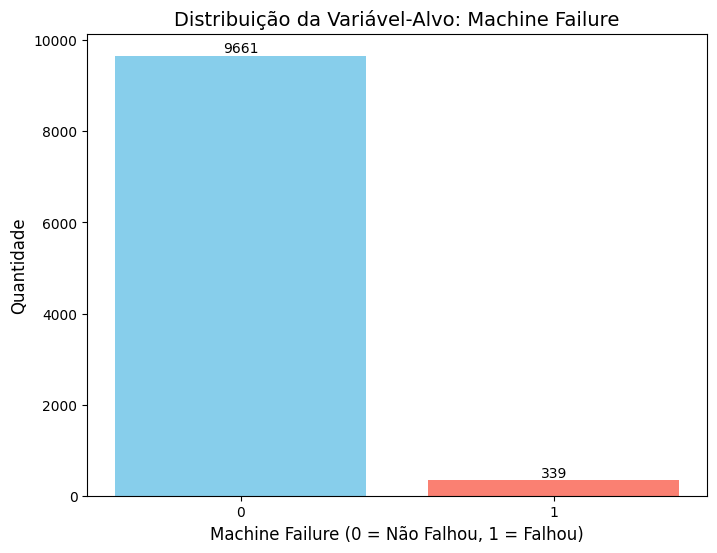


=== DISTRIBUIÇÃO DA VARIÁVEL-ALVO ===
Machine failure
0    9661
1     339
Name: count, dtype: int64

=== PERCENTUAIS ===
Machine failure
0    96.61
1     3.39
Name: proportion, dtype: float64


In [ ]:
contagem = df['Machine failure'].value_counts()
# Criar o gráfico de barras
plt.figure(figsize=(8, 6))
barras = plt.bar(contagem.index.astype(str), contagem.values, color=['skyblue', 'salmon'])
plt.title('Distribuição da Variável-Alvo: Machine Failure', fontsize=14)
plt.xlabel('Machine Failure (0 = Não Falhou, 1 = Falhou)', fontsize=12)
plt.ylabel('Quantidade', fontsize=12)

# Adicionar os valores nas barras
for barra in barras:
    altura = barra.get_height()
    plt.text(barra.get_x() + barra.get_width()/2., altura,
             f'{int(altura)}', ha='center', va='bottom')

plt.show()

# Mostrar também os percentuais
total = len(df)
print("\n=== DISTRIBUIÇÃO DA VARIÁVEL-ALVO ===")
print(df['Machine failure'].value_counts())
print("\n=== PERCENTUAIS ===")
print(df['Machine failure'].value_counts(normalize=True) * 100)

In [ ]:
X = df.drop('Machine failure',axis=1)
y = df['Machine failure']

In [ ]:
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test = train_test_split(
    X,y,test_size=0.2,stratify=y,random_state=42
)
print(f"tamanho do conjunto de treino: {X_train.shape[0]}")
print(f"tamanho do conjunto de teste: {X_test.shape[0]}")
y_train.mean(), y_test.mean()

tamanho do conjunto de treino: 8000
tamanho do conjunto de teste: 2000


(np.float64(0.033875), np.float64(0.034))

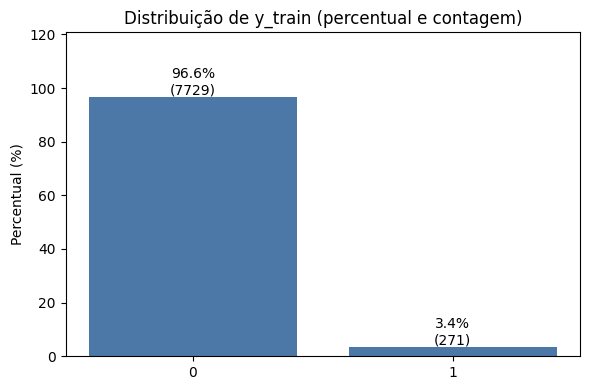

In [ ]:
# Verificar se estamos diante de um conjunto de dados desbalanceados ou não
import matplotlib.pyplot as plt

# Contagem absoluta e percentual
counts = y_train.value_counts().sort_index()
pct = y_train.value_counts(normalize=True).sort_index() * 100

plt.figure(figsize=(6,4))
bars = plt.bar(pct.index.astype(str), pct, color='#4C78A8')

# Adiciona rótulos com percentual + contagem
for bar, val_pct, val_cnt in zip(bars, pct, counts):
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height(),
        f'{val_pct:.1f}%\n({val_cnt})',   # <-- AGORA TEM TAMBÉM A QUANTIDADE
        ha='center',
        va='bottom'
    )

plt.ylabel('Percentual (%)')
plt.title('Distribuição de y_train (percentual e contagem)')
plt.ylim(0, max(pct)*1.25)  # mais folga para caber 2 linhas de texto
plt.tight_layout()
plt.show()

In [ ]:
X_train.nunique()

,0
Type,3
Air temperature [K],93
Process temperature [K],82
Rotational speed [rpm],904
Torque [Nm],566
Tool wear [min],245


## Type

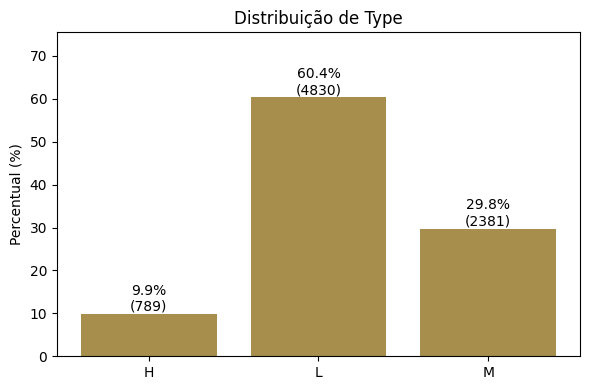

In [ ]:
# Contagem absoluta e percentual
counts = X_train['Type'].value_counts().sort_index()
pct =  X_train['Type'].value_counts(normalize=True).sort_index() * 100

plt.figure(figsize=(6,4))
bars = plt.bar(pct.index.astype(str), pct, color='#a88e4c')

# Adiciona rótulos com percentual + contagem
for bar, val_pct, val_cnt in zip(bars, pct, counts):
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height(),
        f'{val_pct:.1f}%\n({val_cnt})',   # <-- AGORA TEM TAMBÉM A QUANTIDADE
        ha='center',
        va='bottom'
    )

plt.ylabel('Percentual (%)')
plt.title('Distribuição de Type')
plt.ylim(0, max(pct)*1.25)  # mais folga para caber 2 linhas de texto
plt.tight_layout()
plt.show()

**Apesar de um rótulo estar menos representativo que os demais nessa variável(H com 10%), não iremos trata-lo como um rótulo raro pois o mesmo não tem menos de 5% para ser considerado como tal**

**Type é uma variável *categórica ordinal*, pois L -> Low, M -> Medium e H -> High são classificações da qualidade do equipamento**

## Air temperature [K]

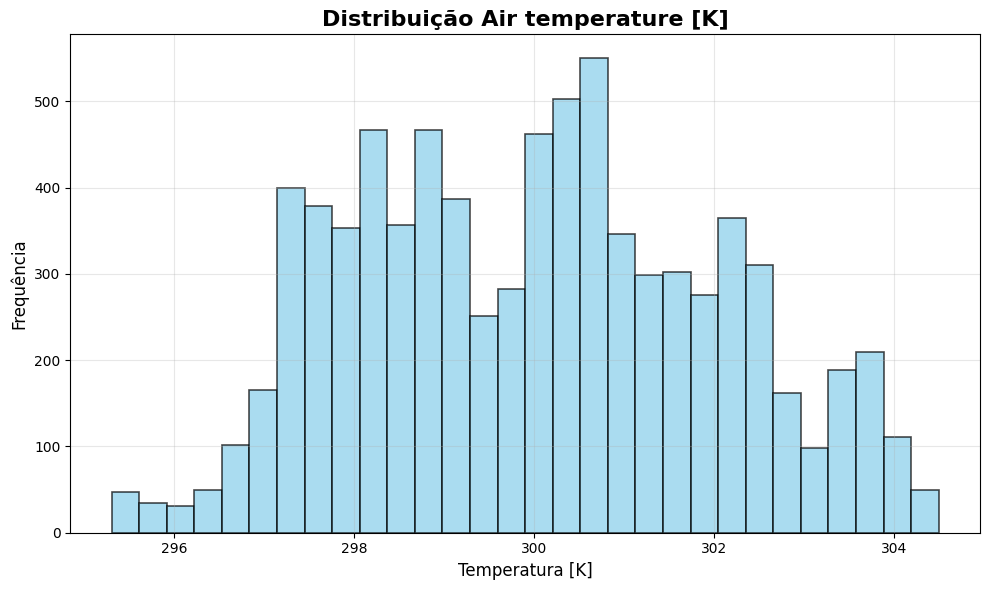

In [ ]:

# Criar o histograma
plt.figure(figsize=(10, 6))
plt.hist(X_train['Air temperature [K]'],
         bins=30,              # número de bins
         edgecolor='black',     # borda das barras
         linewidth=1.2,         # espessura da borda
         alpha=0.7,             # transparência
         color='skyblue')       # cor

# Personalizar
plt.title('Distribuição Air temperature [K]', fontsize=16, fontweight='bold')
plt.xlabel('Temperatura [K]', fontsize=12)
plt.ylabel('Frequência', fontsize=12)
plt.grid(True, alpha=0.3)

# Mostrar
plt.tight_layout()
plt.show()

<Axes: xlabel='Air temperature [K]'>

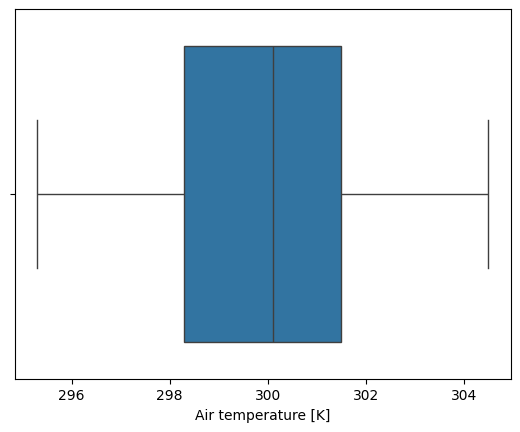

In [ ]:
sns.boxplot(x=X_train['Air temperature [K]'])

**Air Temperature [k] é uma variável numérica contínua e não possui uma distribuição normal assim como também não possui outliers**

## Process temperature [K]

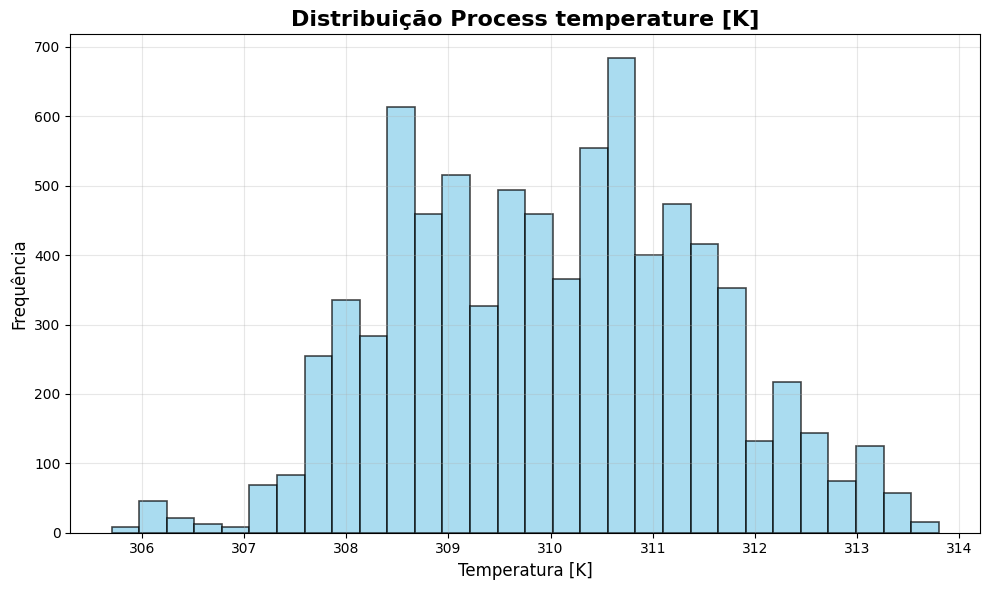

In [ ]:
# Criar o histograma
plt.figure(figsize=(10, 6))
plt.hist(X_train['Process temperature [K]'],
         bins=30,              # número de bins
         edgecolor='black',     # borda das barras
         linewidth=1.2,         # espessura da borda
         alpha=0.7,             # transparência
         color='skyblue')       # cor

# Personalizar
plt.title('Distribuição Process temperature [K]', fontsize=16, fontweight='bold')
plt.xlabel('Temperatura [K]', fontsize=12)
plt.ylabel('Frequência', fontsize=12)
plt.grid(True, alpha=0.3)

# Mostrar
plt.tight_layout()
plt.show()

<Axes: xlabel='Process temperature [K]'>

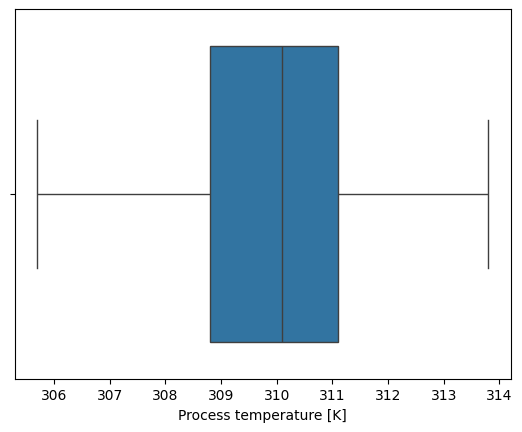

In [ ]:
sns.boxplot(x=X_train['Process temperature [K]'])

**Process Temperature [k] é uma variável numérica contínua e não possui uma distribuição normal assim como também não possui outliers**

##

## Rotational speed [rpm]

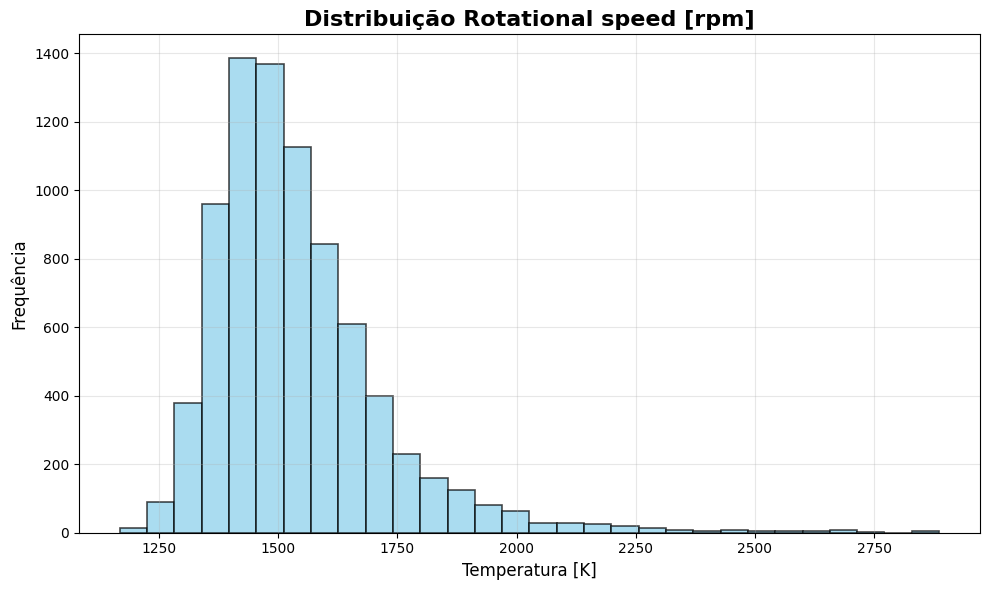

In [ ]:
# Criar o histograma
plt.figure(figsize=(10, 6))
plt.hist(X_train['Rotational speed [rpm]'],
         bins=30,              # número de bins
         edgecolor='black',     # borda das barras
         linewidth=1.2,         # espessura da borda
         alpha=0.7,             # transparência
         color='skyblue')       # cor

# Personalizar
plt.title('Distribuição Rotational speed [rpm]', fontsize=16, fontweight='bold')
plt.xlabel('Temperatura [K]', fontsize=12)
plt.ylabel('Frequência', fontsize=12)
plt.grid(True, alpha=0.3)

# Mostrar
plt.tight_layout()
plt.show()

<Axes: xlabel='Rotational speed [rpm]'>

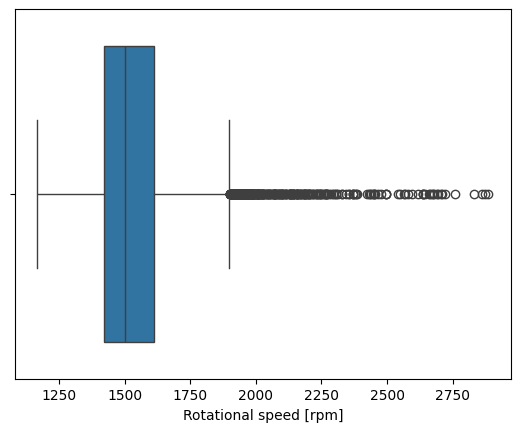

In [ ]:
sns.boxplot(x=X_train['Rotational speed [rpm]'])

**Rotational speed [rpm] é uma variável numérica contínua e não possui uma distribuição normal, pelo indicativo do boxplot possui outliers, no entanto, analisando mais afundo o contexto dos dados, talvez uma máquina girando com tanta velocidade pode fazer parte do modelo de négocio portanto não iremos remover os outliers**

## Torque [Nm]

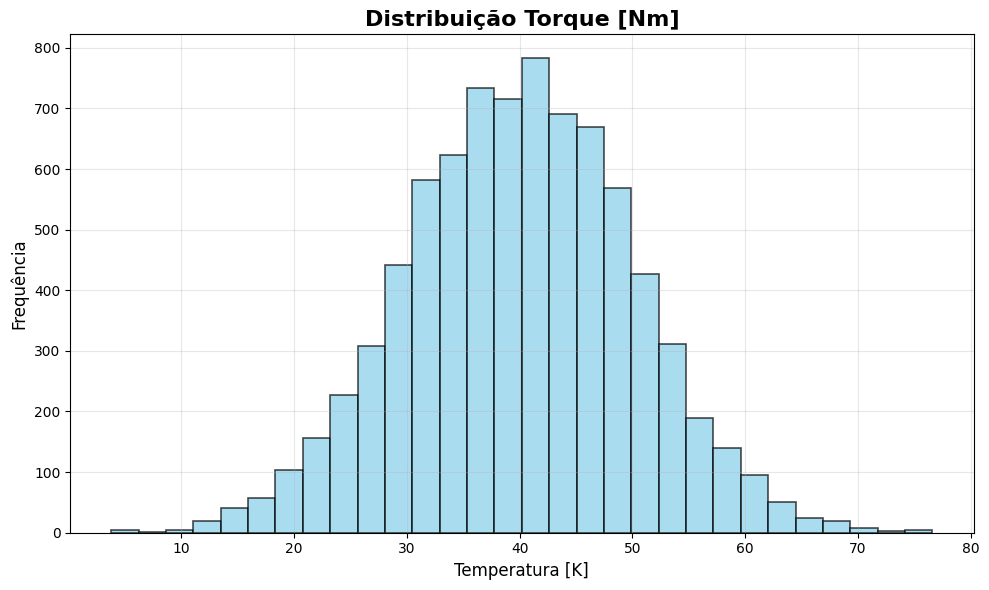

In [ ]:
# Criar o histograma
plt.figure(figsize=(10, 6))
plt.hist(X_train['Torque [Nm]'],
         bins=30,              # número de bins
         edgecolor='black',     # borda das barras
         linewidth=1.2,         # espessura da borda
         alpha=0.7,             # transparência
         color='skyblue')       # cor

# Personalizar
plt.title('Distribuição Torque [Nm]', fontsize=16, fontweight='bold')
plt.xlabel('Temperatura [K]', fontsize=12)
plt.ylabel('Frequência', fontsize=12)
plt.grid(True, alpha=0.3)

# Mostrar
plt.tight_layout()
plt.show()

<Axes: xlabel='Torque [Nm]'>

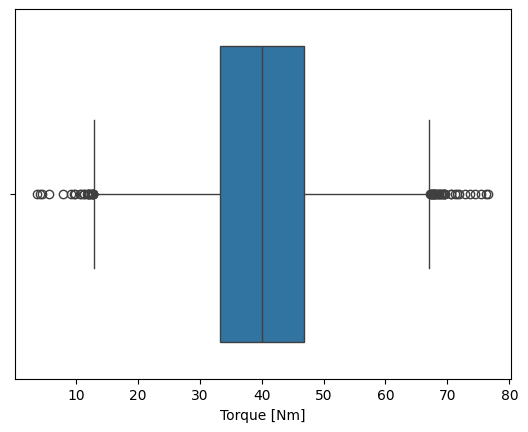

In [ ]:
sns.boxplot(x=X_train['Torque [Nm]'])

**Torque [Nm] é uma variável numérica contínua e não possui uma distribuição normal, pelo indicativo do boxplot possui outliers, no entanto, analisando mais afundo o contexto dos dados, a justificativa para manter os outliers são as mesmas que na variével anterior**

## Tool wear [min]

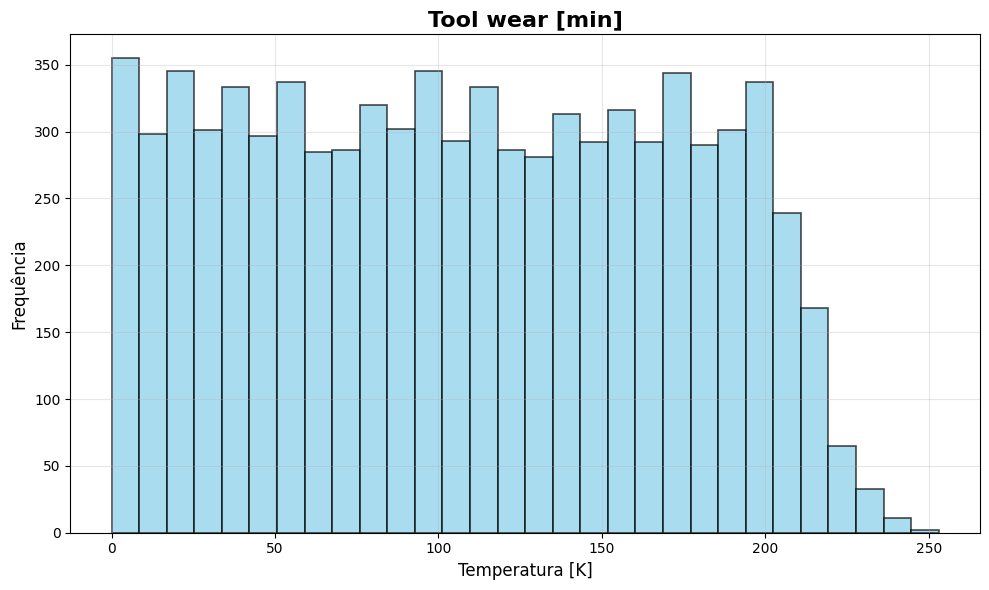

In [ ]:
# Criar o histograma
plt.figure(figsize=(10, 6))
plt.hist(X_train['Tool wear [min]'],
         bins=30,              # número de bins
         edgecolor='black',     # borda das barras
         linewidth=1.2,         # espessura da borda
         alpha=0.7,             # transparência
         color='skyblue')       # cor

# Personalizar
plt.title('Tool wear [min]', fontsize=16, fontweight='bold')
plt.xlabel('Temperatura [K]', fontsize=12)
plt.ylabel('Frequência', fontsize=12)
plt.grid(True, alpha=0.3)

# Mostrar
plt.tight_layout()
plt.show()

<Axes: xlabel='Tool wear [min]'>

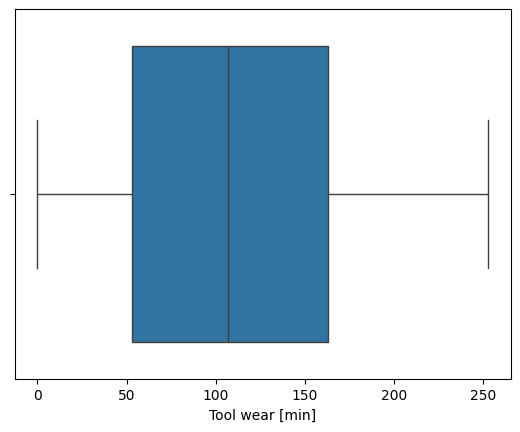

In [ ]:
sns.boxplot(x=X_train['Tool wear [min]'])

**Tool Wear [min] é uma variável numérica contínua e não possui uma distribuição normal assim como também não possui outliers**

## Pré-Processamento

*Faremos a Pipeline de Pré-processamento das variáveis, levando em considereção que estamos em um problema de classificação, desbalanceado e com o intuito de usar como Benchmark o modelo de REGRESSÃO LOGÍSTICA*

In [ ]:
X_train.head()

,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min]
4058,M,302.0,310.9,1456,47.2,54
1221,M,297.0,308.3,1399,46.4,132
6895,M,301.0,311.6,1357,45.6,137
9863,L,298.9,309.8,1411,56.3,84
8711,L,297.1,308.5,1733,28.7,50


In [ ]:
from sklearn.preprocessing import RobustScaler, OrdinalEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

numeric_features = [
    col for col in X_train.columns
    if X_train[col].dtype in ['int64', 'float64']
]

cat_features = ["Type"]

preprocess = ColumnTransformer(
    transformers=[
        ("num", RobustScaler(), numeric_features),
        ("cat",OrdinalEncoder(categories=[['L','M','H']]) , cat_features),
    ],
    remainder="drop",
    verbose_feature_names_out=False
)

In [ ]:
# Aplicar transformação
X_train_array = preprocess.fit_transform(X_train)

# Obter nomes das colunas após transformação (agora com todas as features)
feature_names = numeric_features + cat_features  # Junta todos os nomes

# Criar DataFrame
X_train_processed = pd.DataFrame(
    X_train_array,
    columns=feature_names,
    index=X_train.index
)

In [ ]:
X_train_processed.head()

,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Type
4058,0.59375,0.347826,-0.246073,0.522059,-0.481818,1.0
1221,-0.96875,-0.782609,-0.544503,0.463235,0.227273,1.0
6895,0.28125,0.652174,-0.764398,0.404412,0.272727,1.0
9863,-0.37500,-0.130435,-0.481675,1.191176,-0.209091,0.0
8711,-0.93750,-0.695652,1.204188,-0.838235,-0.518182,0.0


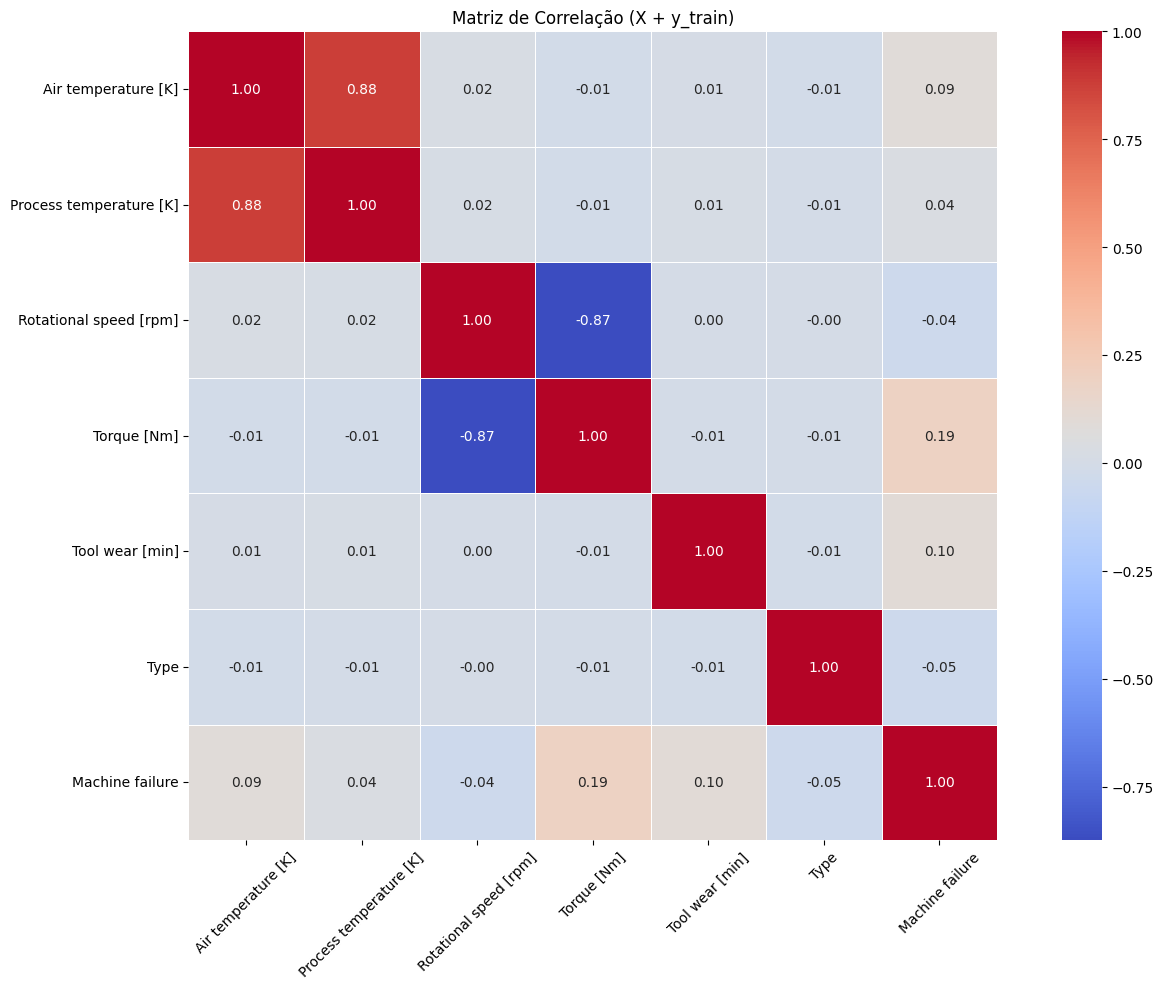

In [ ]:
# Garantir que y_train seja Series
if isinstance(y_train, pd.DataFrame):
    y_train_series = y_train.iloc[:, 0]
else:
    y_train_series = y_train

# Concatenar X e y
df_corr = pd.concat([X_train_processed, y_train_series], axis=1)

# Matriz de correlação
corr_matrix = df_corr.corr()

# Plot
plt.figure(figsize=(14,10))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.5,
    square=True
)

plt.title("Matriz de Correlação (X + y_train)")
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [ ]:
# removendo "Air temperature [K]" e "Torque [Nm]"
X_train_processed.drop(["Air temperature [K]","Torque [Nm]"],axis=1,inplace=True)
X_train_processed.head()

,Process temperature [K],Rotational speed [rpm],Tool wear [min],Type
4058,0.347826,-0.246073,-0.481818,1.0
1221,-0.782609,-0.544503,0.227273,1.0
6895,0.652174,-0.764398,0.272727,1.0
9863,-0.130435,-0.481675,-0.209091,0.0
8711,-0.695652,1.204188,-0.518182,0.0


In [ ]:
X_test_array = preprocess.transform(X_test)

feature_names = numeric_features + cat_features

X_test_processed = pd.DataFrame(
    X_test_array,
    columns=feature_names,
    index=X_test.index
)

In [ ]:
X_test_processed.drop(["Air temperature [K]","Torque [Nm]"],axis=1,inplace=True)
X_test_processed.head()

,Process temperature [K],Rotational speed [rpm],Tool wear [min],Type
2997,-0.130435,-0.827225,0.418182,0.0
4871,1.000000,0.052356,0.254545,0.0
3858,0.565217,0.293194,0.927273,0.0
951,-1.652174,0.031414,-0.427273,2.0
6463,-0.043478,-0.759162,-0.045455,2.0


## Modelagem

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score

# Modelo
log_reg = LogisticRegression(
    class_weight='balanced',
    max_iter=1000,
    random_state=42
)
THRESHOLD = 0.3 # o problema é desbalanceado e o custo de perder uma falha pode ser alto, reduzimos o threshold para aumentar o recall aceitando uma possível queda em precision

# Treino
log_reg.fit(X_train_processed, y_train)

# Obter probabilidades (TREINO)
y_prob_train = log_reg.predict_proba(X_train_processed)[:, 1]

# Aplicar Threshold personalizado (TREINO)
y_pred_train_custom = (y_prob_train >= THRESHOLD).astype(int)

# Avaliação (TREINO)
print(f"Resultados com threshold(TREINO) = {THRESHOLD}")
print(classification_report(y_train, y_pred_train_custom))
print("ROC AUC:", roc_auc_score(y_train, y_prob_train))

# Obter probabilidades (TESTE)
y_prob = log_reg.predict_proba(X_test_processed)[:, 1]

# Aplicar o threshold (TESTE)
y_pred_custom = (y_prob >= THRESHOLD).astype(int)

# Avaliação (TESTE)
print(f"Resultados com threshold(TESTE) = {THRESHOLD}")
print(classification_report(y_test, y_pred_custom))
print("ROC AUC:", roc_auc_score(y_test, y_prob))

Resultados com threshold(TREINO) = 0.3
              precision    recall  f1-score   support

           0       0.98      0.13      0.22      7729
           1       0.04      0.93      0.07       271

    accuracy                           0.15      8000
   macro avg       0.51      0.53      0.15      8000
weighted avg       0.95      0.15      0.22      8000

ROC AUC: 0.6688844763981343
Resultados com threshold(TESTE) = 0.3
              precision    recall  f1-score   support

           0       1.00      0.13      0.23      1932
           1       0.04      0.99      0.07        68

    accuracy                           0.16      2000
   macro avg       0.52      0.56      0.15      2000
weighted avg       0.96      0.16      0.22      2000

ROC AUC: 0.6865104737547193


In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score

THRESHOLD = 0.6

# Modelo Random Forest
rf = RandomForestClassifier(
    n_estimators=400,
    max_depth=7,
    min_samples_split=15,
    min_samples_leaf=8,
    max_features='sqrt',
    class_weight='balanced_subsample',
    random_state=42,
    n_jobs=-1
)

# Treino
rf.fit(X_train_processed, y_train)

y_prob_train_rf = rf.predict_proba(X_train_processed)[:, 1]
y_pred_train_rf = (y_prob_train_rf >= THRESHOLD).astype(int)

# Avaliação no treino
print(f"Resultados Random Forest (TREINO) - threshold = {THRESHOLD}")
print(classification_report(y_train, y_pred_train_rf))
print("ROC AUC:", roc_auc_score(y_train, y_prob_train_rf))

# Probabilidades no teste
y_prob_rf = rf.predict_proba(X_test_processed)[:, 1]

# Threshold personalizado no teste
y_pred_rf = (y_prob_rf >= THRESHOLD).astype(int)

# Avaliação no teste
print(f"Resultados Random Forest (TESTE) - threshold = {THRESHOLD}")
print(classification_report(y_test, y_pred_rf))
print("ROC AUC:", roc_auc_score(y_test, y_prob_rf))

Resultados Random Forest (TREINO) - threshold = 0.6
              precision    recall  f1-score   support

           0       0.99      0.93      0.96      7729
           1       0.32      0.86      0.46       271

    accuracy                           0.93      8000
   macro avg       0.66      0.90      0.71      8000
weighted avg       0.97      0.93      0.95      8000

ROC AUC: 0.9699020175607371
Resultados Random Forest (TESTE) - threshold = 0.6
              precision    recall  f1-score   support

           0       0.99      0.93      0.96      1932
           1       0.29      0.76      0.42        68

    accuracy                           0.93      2000
   macro avg       0.64      0.85      0.69      2000
weighted avg       0.97      0.93      0.94      2000

ROC AUC: 0.9297664718061138


In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
#checar se 0,6 pra threshold foi a melhor opção
thresholds = [0.2, 0.3, 0.4, 0.5, 0.6, 0.7]

resultados_threshold = []

for t in thresholds:
    y_pred_t = (y_prob_rf >= t).astype(int)

    resultados_threshold.append({
        "Threshold": t,
        "Acurácia": accuracy_score(y_test, y_pred_t),
        "Precision": precision_score(y_test, y_pred_t, zero_division=0),
        "Recall": recall_score(y_test, y_pred_t, zero_division=0),
        "F1-Score": f1_score(y_test, y_pred_t, zero_division=0)
    })

pd.DataFrame(resultados_threshold)

,Threshold,Acurácia,Precision,Recall,F1-Score
0,0.2,0.8360,0.163212,0.926471,0.277533
1,0.3,0.8710,0.195513,0.897059,0.321053
2,0.4,0.8930,0.223485,0.867647,0.355422
3,0.5,0.9145,0.260465,0.823529,0.395760
4,0.6,0.9270,0.285714,0.764706,0.416000
5,0.7,0.9410,0.310606,0.602941,0.410000


In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

def resumo_metricas(y_true, y_pred, y_prob, nome_modelo, base):
    return {
        "Modelo": nome_modelo,
        "Base": base,
        "Acurácia": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred, zero_division=0),
        "Recall": recall_score(y_true, y_pred, zero_division=0),
        "F1-Score": f1_score(y_true, y_pred, zero_division=0),
        "ROC AUC": roc_auc_score(y_true, y_prob)
    }

resumos = []

resumos.append(resumo_metricas(y_train, y_pred_train_custom, y_prob_train, "Regressão Logística", "Treino"))
resumos.append(resumo_metricas(y_test, y_pred_custom, y_prob, "Regressão Logística", "Teste"))

resumos.append(resumo_metricas(y_train, y_pred_train_rf, y_prob_train_rf, "Random Forest", "Treino"))
resumos.append(resumo_metricas(y_test, y_pred_rf, y_prob_rf, "Random Forest", "Teste"))

pd.DataFrame(resumos)

,Modelo,Base,Acurácia,Precision,Recall,F1-Score,ROC AUC
0,Regressão Logística,Treino,0.152500,0.035801,0.926199,0.068937,0.668884
1,Regressão Logística,Teste,0.157000,0.038242,0.985294,0.073626,0.686510
2,Random Forest,Treino,0.932375,0.316576,0.859779,0.462761,0.969902
3,Random Forest,Teste,0.927000,0.285714,0.764706,0.416000,0.929766


In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

resultados = pd.DataFrame({
    "Modelo": ["Regressão Logística", "Random Forest"],
    "Acurácia": [
        accuracy_score(y_test, y_pred_custom),
        accuracy_score(y_test, y_pred_rf)
    ],
    "Precision": [
        precision_score(y_test, y_pred_custom),
        precision_score(y_test, y_pred_rf)
    ],
    "Recall": [
        recall_score(y_test, y_pred_custom),
        recall_score(y_test, y_pred_rf)
    ],
    "F1-Score": [
        f1_score(y_test, y_pred_custom),
        f1_score(y_test, y_pred_rf)
    ],
    "ROC AUC": [
        roc_auc_score(y_test, y_prob),
        roc_auc_score(y_test, y_prob_rf)
    ]
})

resultados

,Modelo,Acurácia,Precision,Recall,F1-Score,ROC AUC
0,Regressão Logística,0.157,0.038242,0.985294,0.073626,0.686510
1,Random Forest,0.927,0.285714,0.764706,0.416000,0.929766
